In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv', encoding='utf-8-sig')

print(f'shape: {df.shape}')
print(f'폐업률 범위: {df["폐업률"].min():.2f}% ~ {df["폐업률"].max():.2f}%')
print(df.head(3))

shape: (1050, 25)
폐업률 범위: 1.98% ~ 23.76%
    구명    연도     업종       평균_당월매출     연령대_20_매출     연령대_30_매출     연령대_40_매출  \
0  강남구  2019  분식전문점  6.533841e+08  1.279386e+08  1.448395e+08  1.427872e+08   
1  강남구  2019  양식음식점  1.366631e+09  2.688714e+08  3.211270e+08  2.250849e+08   
2  강남구  2019  일식음식점  9.675838e+08  1.774149e+08  2.076301e+08  1.397524e+08   

      연령대_50_매출  주말_매출_비율    폐업률  ...  출근시간_유동인구_06_11  점심시간_유동인구_11_14  \
0  8.195965e+07    0.2211   7.82  ...    186583.436893    149304.470874   
1  1.425676e+08    0.2955   9.90  ...    186583.436893    149304.470874   
2  8.413404e+07    0.1966  10.23  ...    186583.436893    149304.470874   

   저녁시간_유동인구_17_21          평균_승차          평균_하차    총_직장인구  직장인구_20대  \
0    172608.453883  604128.458333  630089.903646  937043.0  186311.0   
1    172608.453883  604128.458333  630089.903646  937043.0  186311.0   
2    172608.453883  604128.458333  630089.903646  937043.0  186311.0   

   직장인구_30대  직장인구_40대  직장인구_50대  
0  286727.0  23893

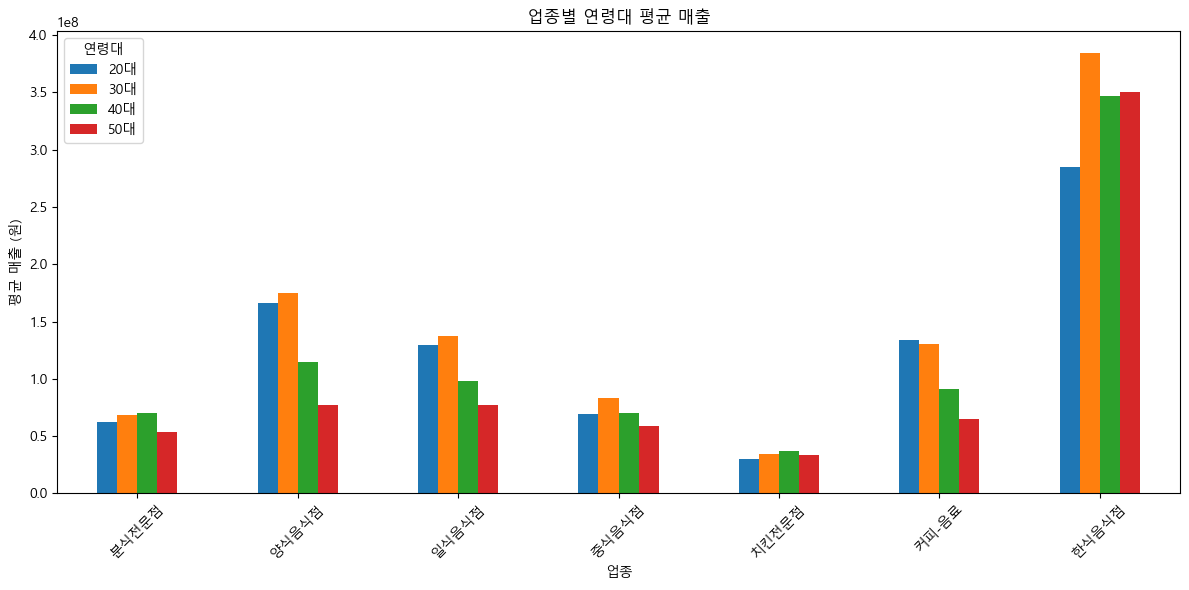

               20대          30대          40대          50대
업종                                                       
분식전문점   62664445.0   68681636.0   70200646.0   53841094.0
양식음식점  165806887.0  174910036.0  114714312.0   76819424.0
일식음식점  129257689.0  137594304.0   97879242.0   77079845.0
중식음식점   69418002.0   83282749.0   70053901.0   59177335.0
치킨전문점   30366011.0   34326533.0   37043782.0   33282103.0
커피-음료  133661675.0  130183849.0   91435366.0   64977904.0
한식음식점  284573277.0  384127443.0  347191957.0  350749193.0


In [2]:
age_cols = ['연령대_20_매출', '연령대_30_매출', '연령대_40_매출', '연령대_50_매출']

df_age = df.groupby('업종')[age_cols].mean()
df_age.columns = ['20대', '30대', '40대', '50대']

df_age.plot(kind='bar', figsize=(12, 6))
plt.title('업종별 연령대 평균 매출')
plt.xlabel('업종')
plt.ylabel('평균 매출 (원)')
plt.xticks(rotation=45)
plt.legend(title='연령대')
plt.tight_layout()
plt.show()

print(df_age.round(0))

#### 한식의 압도적인 이유
#### 가장 보편적인 외식업종
#### 매장수 자체가 가장 많아서 매출 합계 도 높음
#### 모든 연령대에서 고르게 소비






#### 양식/일식 → 20대, 30대 비중 높음 젊은 층이 선호

#### 커피-음료  → 20대 매출이 30대보다 높음 카페는 20대가 주도

In [12]:
# 구별 주요 연령대 + 폐업률 낮은 업종
df_q6 = df.groupby(['구명', '업종']).agg(
    평균_폐업률=('폐업률', 'mean'),
    연령_20대=('유동인구_20대', 'mean'),
    연령_30대=('유동인구_30대', 'mean'),
    연령_40대=('유동인구_40대', 'mean'),
    연령_50대=('유동인구_50대', 'mean'),
).reset_index()

# 주요 연령대 찾기
age_cols = ['연령_20대', '연령_30대', '연령_40대', '연령_50대']
df_q6['주요연령대'] = df_q6[age_cols].idxmax(axis=1).str.replace('연령_', '')

print(df_q6.groupby(['주요연령대', '업종'])['평균_폐업률'].mean().unstack().round(2))

업종     분식전문점  양식음식점  일식음식점  중식음식점  치킨전문점  커피-음료  한식음식점
주요연령대                                                 
20대    10.13  11.30   9.59   8.51   9.69  12.37   8.64
30대     9.18  10.62   9.48   8.57   9.76  12.09   8.64
40대    11.13  11.34  11.26   9.32   9.86  13.58   9.92
50대     9.75  10.60   9.58   8.14   8.77  12.48   9.56


#### 커피-음료(카폐)는 연령대 불문 압도적인 폐업률을 보여준다


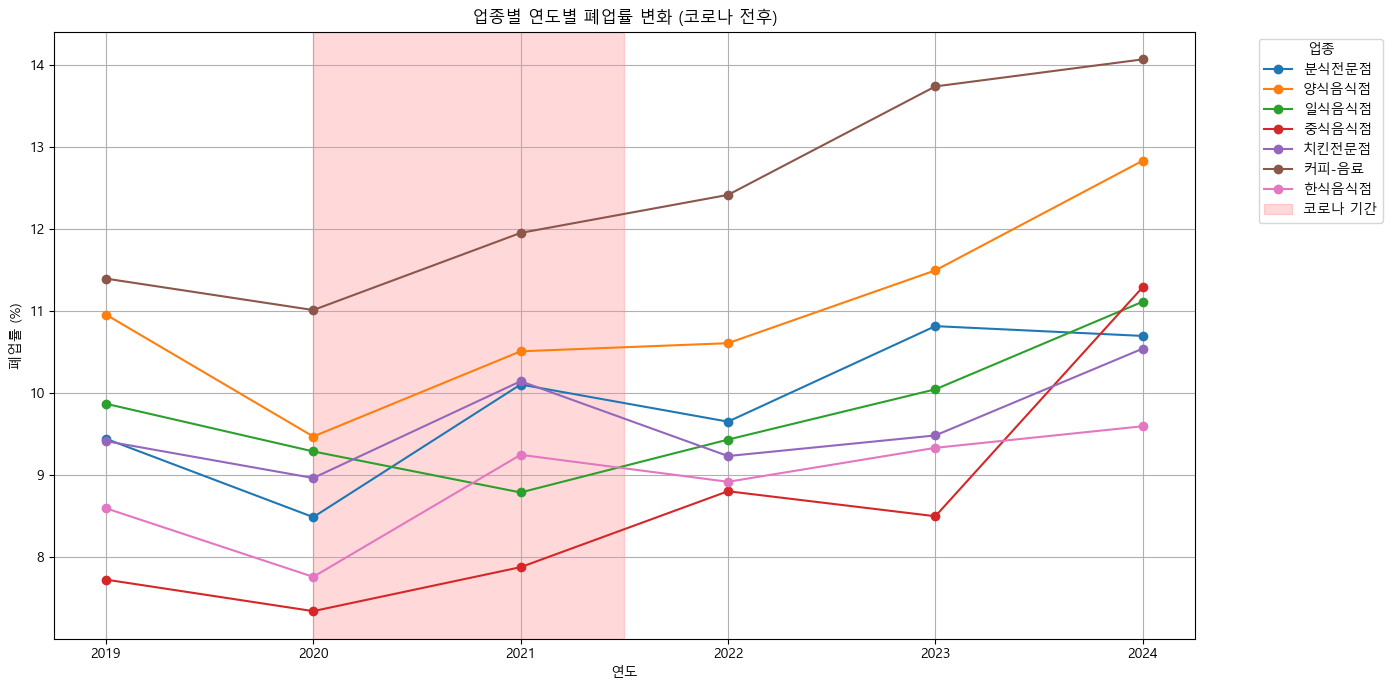

In [4]:
df_covid = df.groupby(['연도', '업종'])['폐업률'].mean().reset_index()

plt.figure(figsize=(14, 7))
for 업종 in df_covid['업종'].unique():
    temp = df_covid[df_covid['업종'] == 업종]
    plt.plot(temp['연도'], temp['폐업률'], marker='o', label=업종)

plt.axvspan(2020, 2021.5, alpha=0.15, color='red', label='코로나 기간')
plt.title('업종별 연도별 폐업률 변화 (코로나 전후)')
plt.xlabel('연도')
plt.ylabel('폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 코로나 기간(2020~2021) 평균 폐업률 9.8%  생각보다 낮은 이유는 사실상 착시 효과 이다
#### 정부의 전방위적인 지원책과 대출 유예조치로 폐업을 미루며 버틴 매장이 많다
#### 정부 지원금, 대출 만기 연장 및 이자 상환 유예 등 
#### 버티기의 결과 는 폐업 폭탄으로 이어졌다
#### 지원책이 멈추자마자 한꺼번에 무너지기 시작
#### 엔데믹 이후(2022~2024) 평균 폐업률 11.4% 정부 지원금이 전면 중단 -> 폐업률 상승으로 이어짐

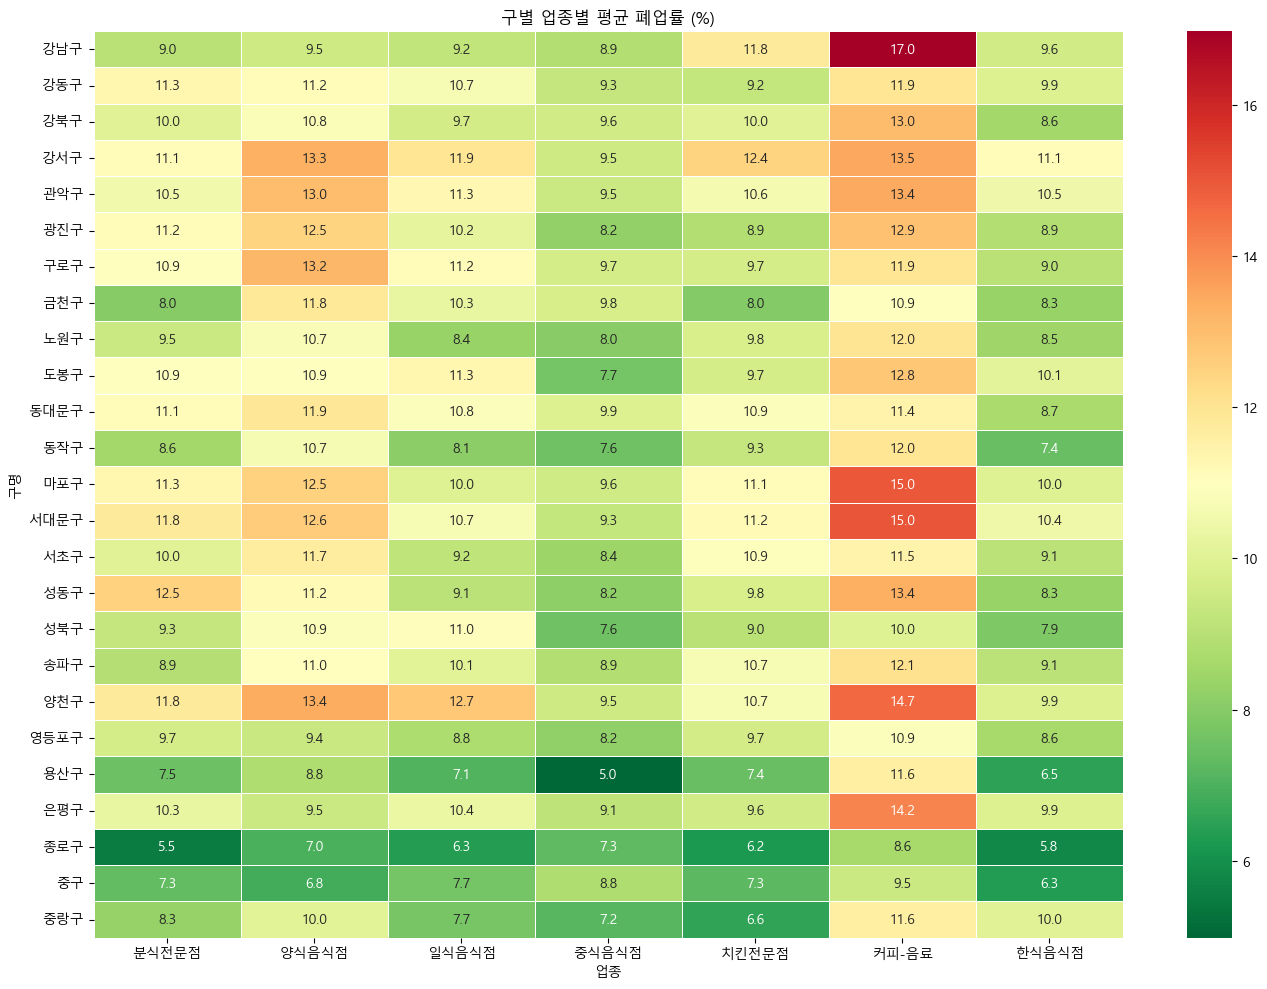

In [5]:
df_pivot = df.groupby(['구명', '업종'])['폐업률'].mean().unstack()

plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('구별 업종별 평균 폐업률 (%)')
plt.xlabel('업종')
plt.ylabel('구명')
plt.tight_layout()
plt.show()

#### 커피-음료(카폐)는 전 업종 통틀어 폐업률 압도적 1위 초과포화 상태
#### 폐업 수가 압도적인 곳: 강남구, 마포구,서대문구
#### 오피스 밀집 지역 및 대형 핫플레이스 상권, 트렌드 또는 상권이 힘을 잃으면서 밀려나는 침체형 폐업
#### 기술적 장벽 낮음, 낮은 창업 비용 등 창업자가 끊이지 않고 그만큼 폐업자도 쏟아지는 구조


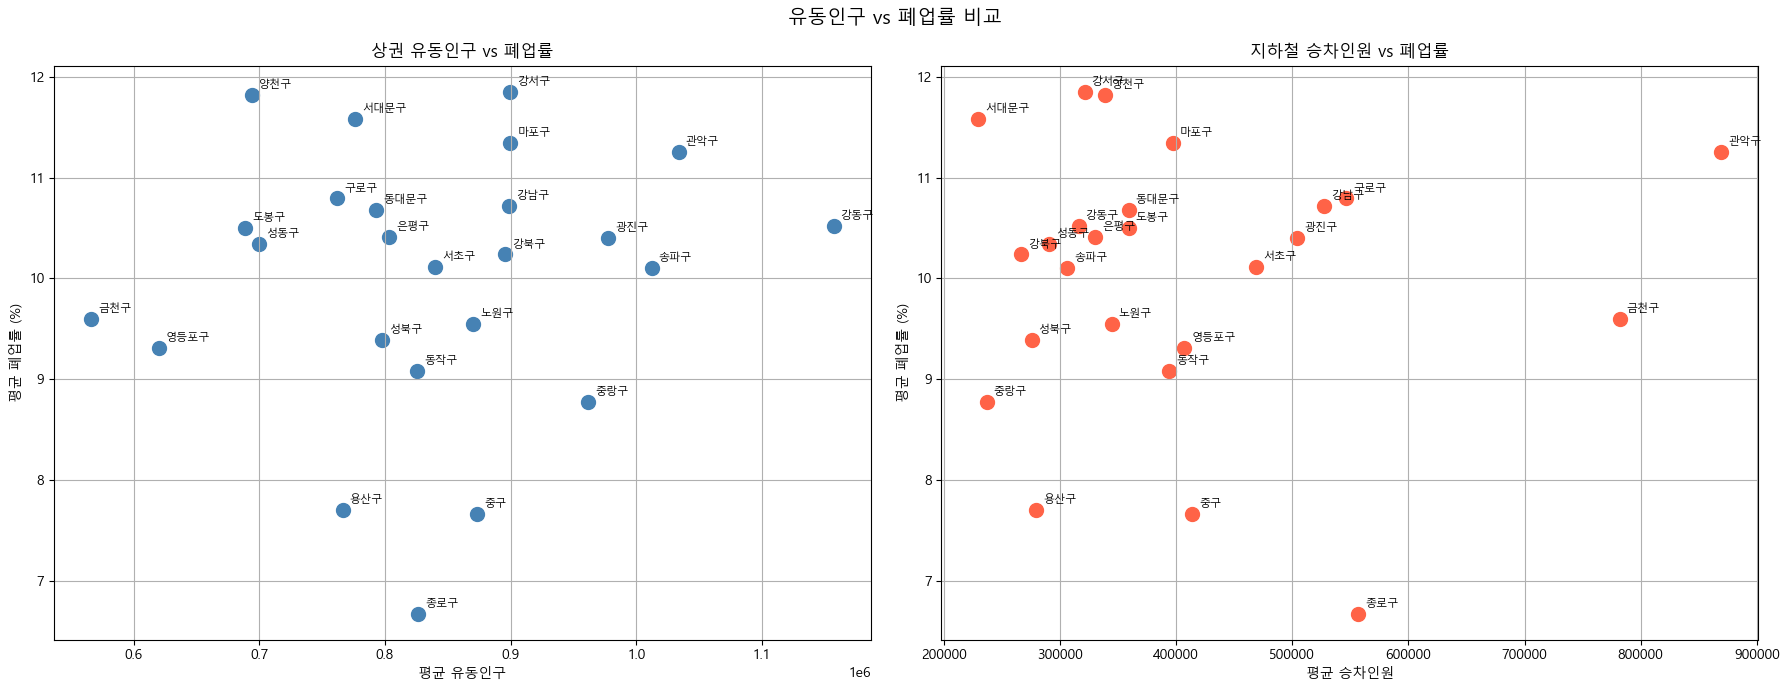

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 상권 유동인구 vs 폐업률
df_scatter = df.groupby('구명').agg(
    평균_유동인구=('총_유동인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

axes[0].scatter(df_scatter['평균_유동인구'],
                df_scatter['평균_폐업률'],
                s=100, color='steelblue')
for _, row in df_scatter.iterrows():
    axes[0].annotate(row['구명'],
                    (row['평균_유동인구'], row['평균_폐업률']),
                    textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
axes[0].set_title('상권 유동인구 vs 폐업률')
axes[0].set_xlabel('평균 유동인구')
axes[0].set_ylabel('평균 폐업률 (%)')
axes[0].grid(True)

# 오른쪽: 지하철 승차 vs 폐업률
df_subway_scatter = df.groupby('구명').agg(
    평균_승차=('평균_승차', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

axes[1].scatter(df_subway_scatter['평균_승차'],
                df_subway_scatter['평균_폐업률'],
                s=100, color='tomato')
for _, row in df_subway_scatter.iterrows():
    axes[1].annotate(row['구명'],
                    (row['평균_승차'], row['평균_폐업률']),
                    textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
axes[1].set_title('지하철 승차인원 vs 폐업률')
axes[1].set_xlabel('평균 승차인원')
axes[1].set_ylabel('평균 폐업률 (%)')
axes[1].grid(True)

plt.suptitle('유동인구 vs 폐업률 비교', fontsize=14)
plt.tight_layout()
plt.show()

#### 사람이 많이 다닌다고 해서 식당이 안 망하는 것은 아니다
#### 유동인구가 많으면 폐업률이 낮다? -> 상관관계 약함
#### 지하철 승차인원이 많으면 상권이 탄탄하다 -> 상관관계 약함
#### 임대료의 역설 - 유동인구가 많은 곳은 보통 임대료가 비싸다 
#### 유동인구 덕에 매출은 높을지 몰라도, 임대료와 인건비를 내고 나면 남는 게 없이 폐업 (ex: 강남, 마포, 관악)
#### 업종 밀집도 유동인구가 많은 곳이 많은 창업으로 이어진다
#### 종로구는 노포 중심 + 고정 오피스 수요로 유동인구와 무관하게 폐업률이 낮게 유지된다
#### 강남구 평균 매출 1위 → 폐업률 9%"
#### 관악구 유동인구 103만 → 폐업률 11.3%

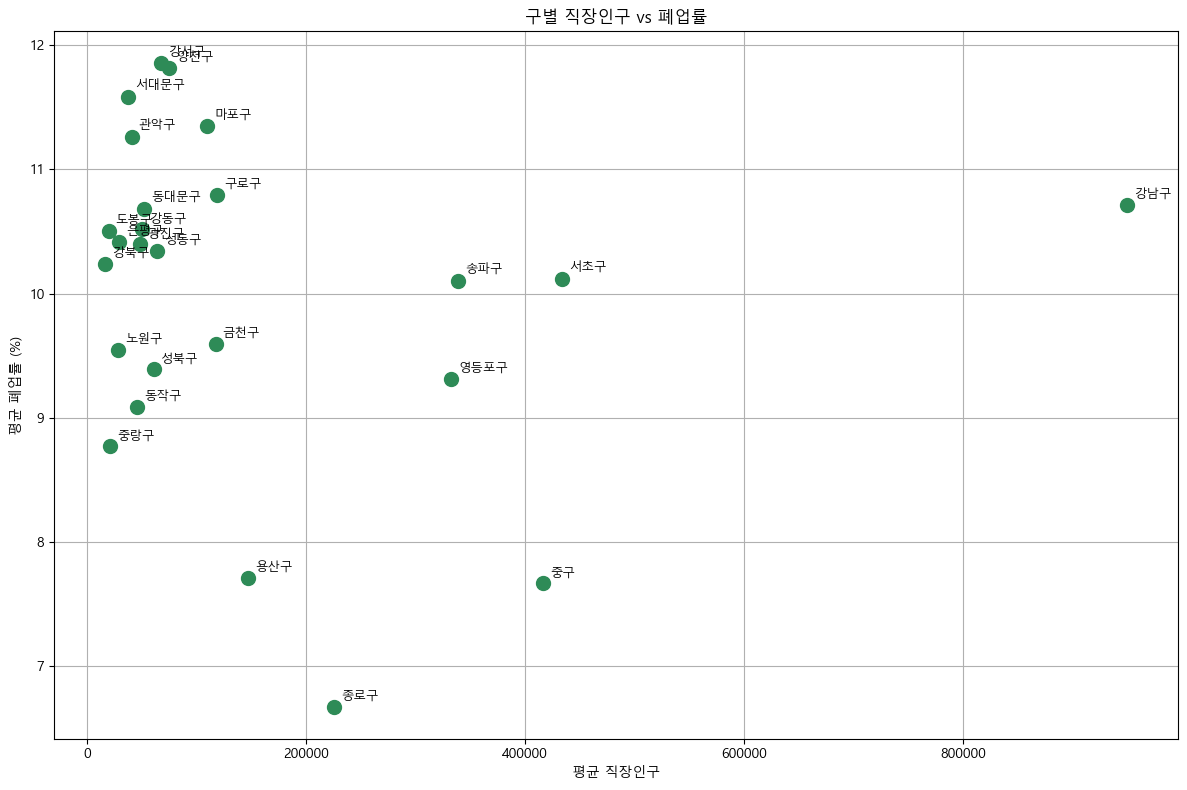

In [8]:
df_work_scatter = df.groupby('구명').agg(
    평균_직장인구=('총_직장인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_work_scatter['평균_직장인구'],
            df_work_scatter['평균_폐업률'],
            s=100, color='seagreen')

for _, row in df_work_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_직장인구'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 직장인구 vs 폐업률')
plt.xlabel('평균 직장인구')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
구_list = ['강서구', '양천구', '서대문구', '관악구']

df_check = df[df['구명'].isin(구_list)].groupby(['구명', '업종'])['폐업률'].mean().unstack()
print(df_check.round(2))

업종    분식전문점  양식음식점  일식음식점  중식음식점  치킨전문점  커피-음료  한식음식점
구명                                                   
강서구   11.15  13.31  11.94   9.51  12.45  13.47  11.14
관악구   10.52  13.03  11.28   9.46  10.63  13.43  10.48
서대문구  11.79  12.64  10.74   9.28  11.19  15.03  10.42
양천구   11.80  13.39  12.74   9.48  10.74  14.66   9.93


#### 직장인은 없는데 경쟁은 치열 
#### 주거 밀집 지역 (강서, 양천, 서대문, 관악) 은 진입장벽이 낮은 배달전문점, 커피, 치킨전문점 창업이 높은편
#### 커피-음료 평균 폐업률 14.15% ,치킨전문점 평균 폐업률 11.25%
#### 직장인 상권처럼 점심/저녁 회식 같은 '확실한 객단가'가 보장되지 않고, 동네 주민만을 대상으로 치열한 가격 경쟁
#### 직장인이 적은 곳에서 폐업률이 치솟는 현상
#### 강남구의 역설: 직장인이 압도적이지만 폐업도 압도적 직장인 인구 1위, 매출액 1위지만 임대료와 권리금도 서울 1위
#### 이 데이터에 확장 가능성 '임대료' 변수를 한 번 더 섞으면 강남구가 왜 저렇게 높은 위치에 있는지 더 명확해질 것

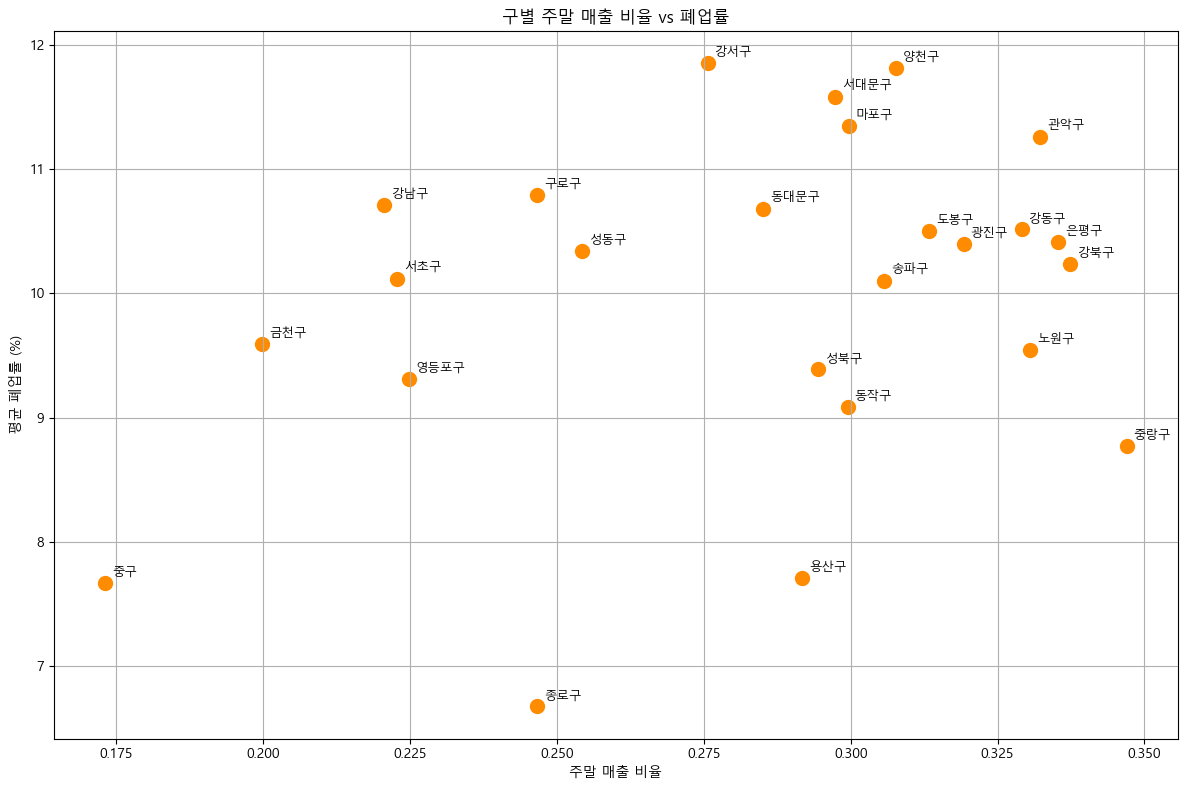

In [10]:
df_weekend = df.groupby('구명').agg(
    평균_주말비율=('주말_매출_비율', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_weekend['평균_주말비율'],
            df_weekend['평균_폐업률'],
            s=100, color='darkorange')

for _, row in df_weekend.iterrows():
    plt.annotate(row['구명'],
                (row['평균_주말비율'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 주말 매출 비율 vs 폐업률')
plt.xlabel('주말 매출 비율')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 주말 매출 비중이 높다 = 주간 직장인 수요가 없다 = 평일 고정 수요 없음 = 매출 변동성 높음 = 폐업 위험
#### 구별 직장인구 vs 폐업률 과 구별 주말 매출 비율 vs 폐업률 비교 하면 더욱 뚜렷해지는 결과
#### 주거 밀집지 0.325 이상 → 평균 폐업률 10 ~ 12% (강동구, 은평구, 강북구, 중랑구, 노원구) 일주일 중 단 이틀(주말) 매출에 목을 매야 하는 구조
#### 직장인 상권 중구와 종로구 주말 매출 비율이 0.175 ~ 0.25 수준 으로 매우 낮음 → 평균 폐업률 7~9%"
#### 강남구의 '특이점' 재확인  주말 매출 비중이 약 0.22로 매우 낮은편 논리적으로는 종로·중구처럼 폐업률이 낮아야 하는데, 강남구는 폐업률이 11% 육박

#### 중랑구: 직장인수 최하위권 인데 폐업률도 최하위권(8%대) 생계형 노포와 저렴한 임대료 같은 케이스
#### 용산구: 직장인구 대비 폐업률이 매우 낮게(7%대)  독점적 핫플레이스의 힘 ( 용리단길, 한남동, 이태원 등) 은 대체 불가능한 상권
#### 고정비 대비 수요가 안정적

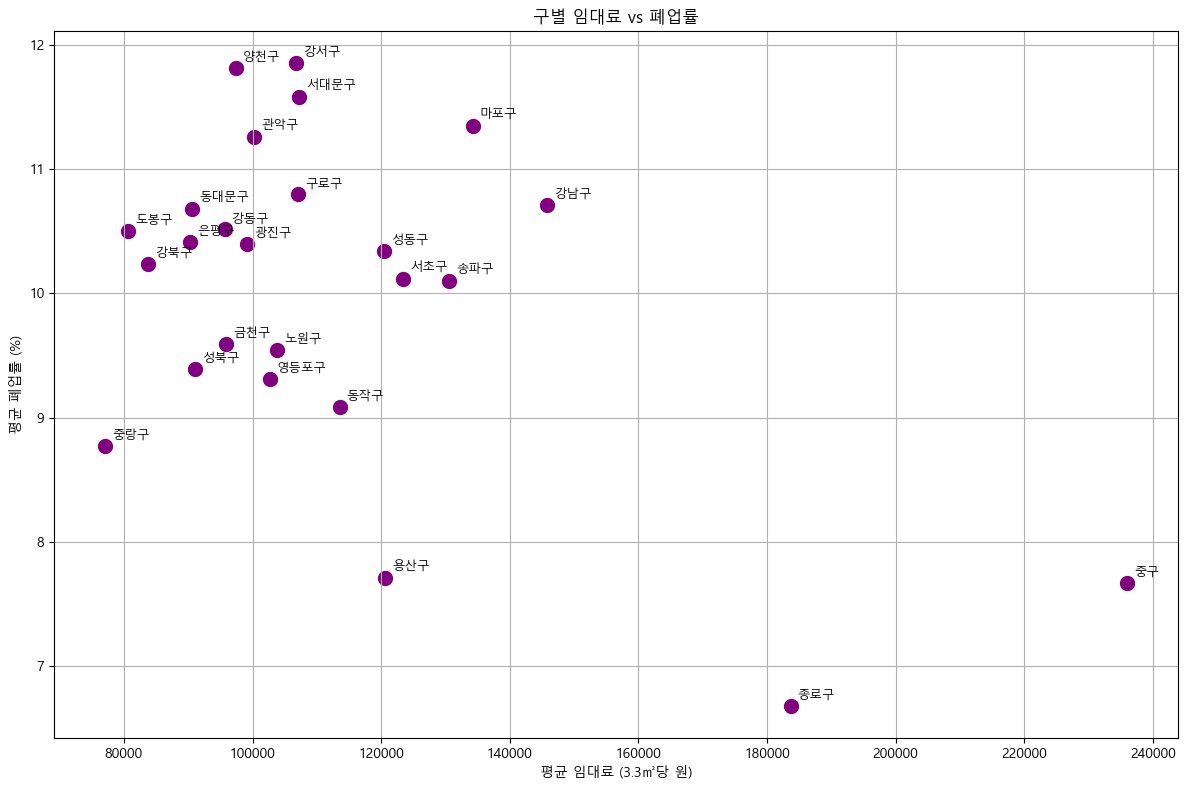

In [13]:
df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv',
                 encoding='utf-8-sig')

df_rent_scatter = df.groupby('구명').agg(
    평균_임대료=('임대료', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_rent_scatter['평균_임대료'],
            df_rent_scatter['평균_폐업률'],
            s=100, color='purple')

for _, row in df_rent_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_임대료'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 임대료 vs 폐업률')
plt.xlabel('평균 임대료 (3.3㎡당 원)')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

####  임대료가 비싼데 폐업률이 낮은 곳도 있고 높은 곳도 있어. 임대료 단독으로는 설명 불가

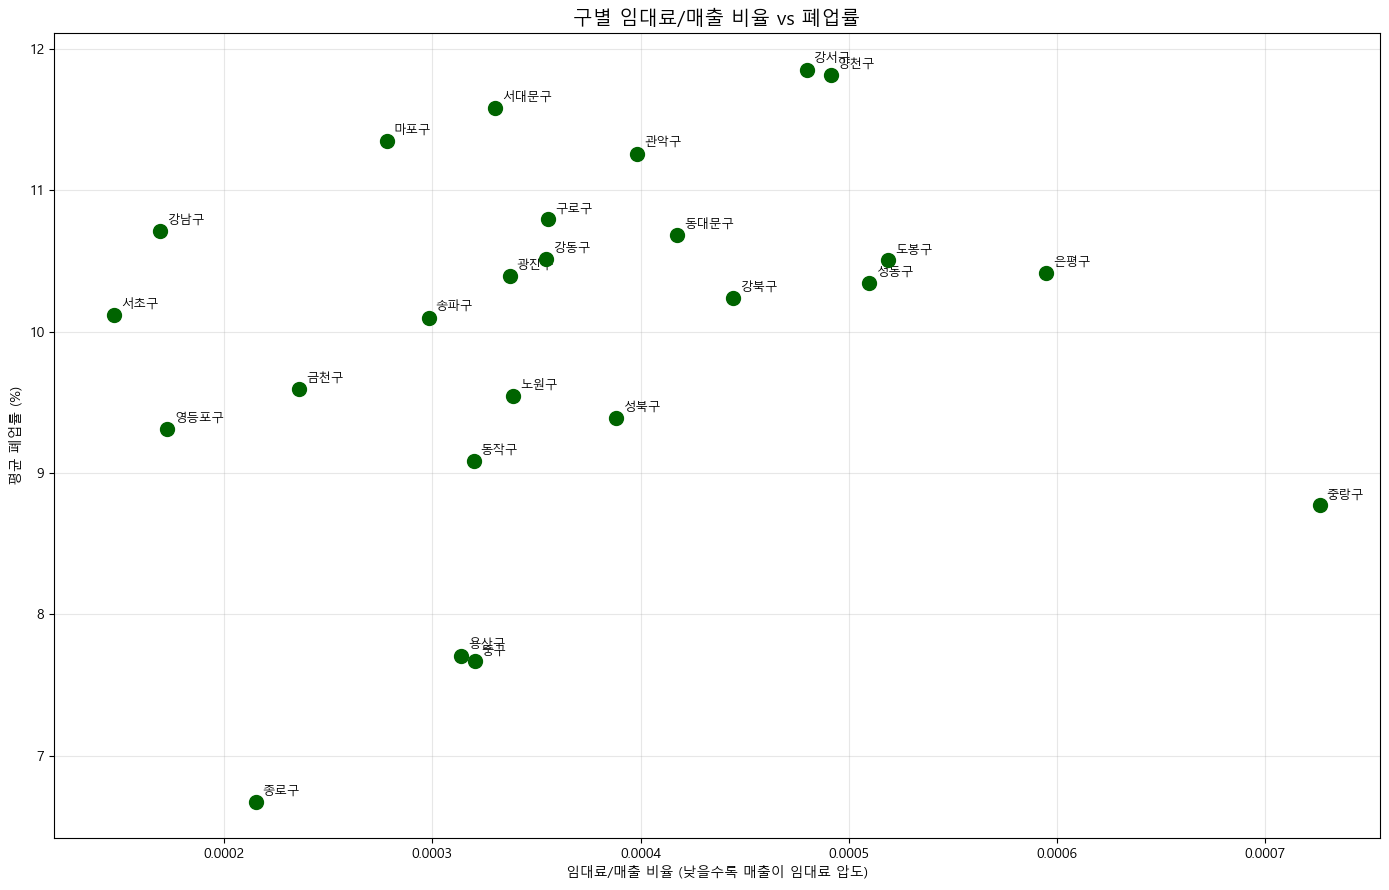

In [32]:
fig, ax = plt.subplots(figsize=(14, 9))

# 산점도
for _, row in df_ratio_scatter.iterrows():
    ax.scatter(row['평균_임대료매출비율'], row['평균_폐업률'],
               s=100, color='darkgreen', zorder=5)
    ax.annotate(row['구명'],
               (row['평균_임대료매출비율'], row['평균_폐업률']),
               textcoords='offset points',
               xytext=(5, 5), fontsize=9)




ax.set_title('구별 임대료/매출 비율 vs 폐업률', fontsize=14)
ax.set_xlabel('임대료/매출 비율 (낮을수록 매출이 임대료 압도)')
ax.set_ylabel('평균 폐업률 (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 임대료 단독으로 폐업률 설명이 불가능  → 임대료 대비 매출 비율로 분석을 확장
#### 강남구/서초구는 임대료 대비 매출 비율이 서울에서 가장 낮은데도 폐업률이 10% 이상 → 
#### 매출이 임대료를 압도해도 폐업률이 높음 → 경쟁 과열이 핵심 원인 아닌지 추측
#### 경쟁 과열이 실제로 핵심 원인 분석 해보기


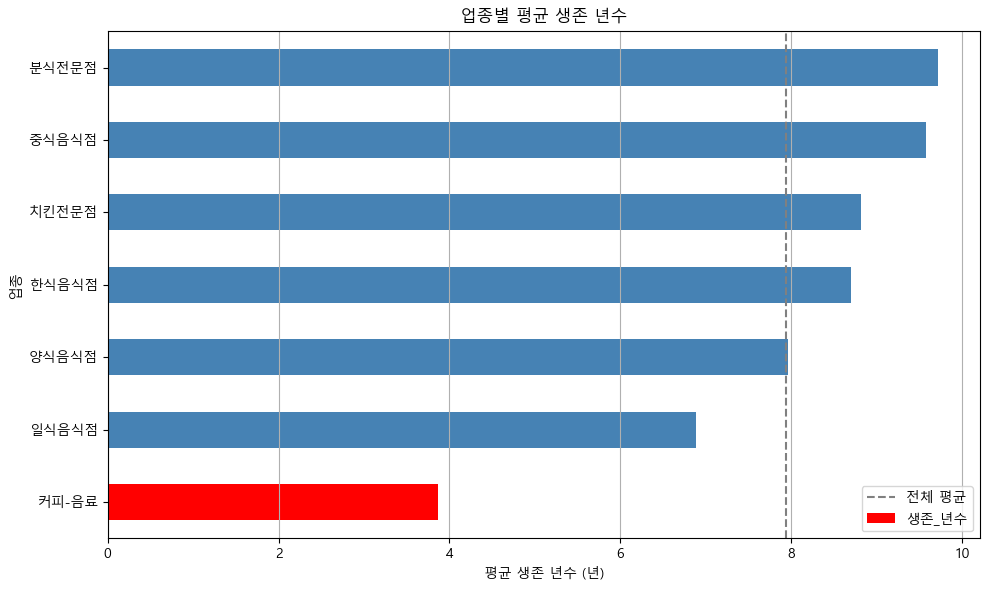

업종
커피-음료    3.9
일식음식점    6.9
양식음식점    8.0
한식음식점    8.7
치킨전문점    8.8
중식음식점    9.6
분식전문점    9.7
Name: 생존_년수, dtype: float64


In [37]:
df_survival_year = df_closed_all.groupby('업종')['생존_년수'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if 업종 == '커피-음료' else 'steelblue' for 업종 in df_survival_year.index]
df_survival_year.plot(kind='barh', color=colors)

plt.title('업종별 평균 생존 년수')
plt.xlabel('평균 생존 년수 (년)')
plt.ylabel('업종')
plt.axvline(x=df_survival_year.mean(), color='gray', linestyle='--', label='전체 평균')
plt.legend()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print(df_survival_year.round(1))

#### 업종별 생존 년수 를 볼때 확실히  커피-음료(카폐)의 수명이 짧음
#### 경쟁강도가 더욱 심화 될수 밖에 없는 부분
#### 지역의 선택도 중요 하지만 업종의 선택 또한 폐업률의 큰 영향을 줌

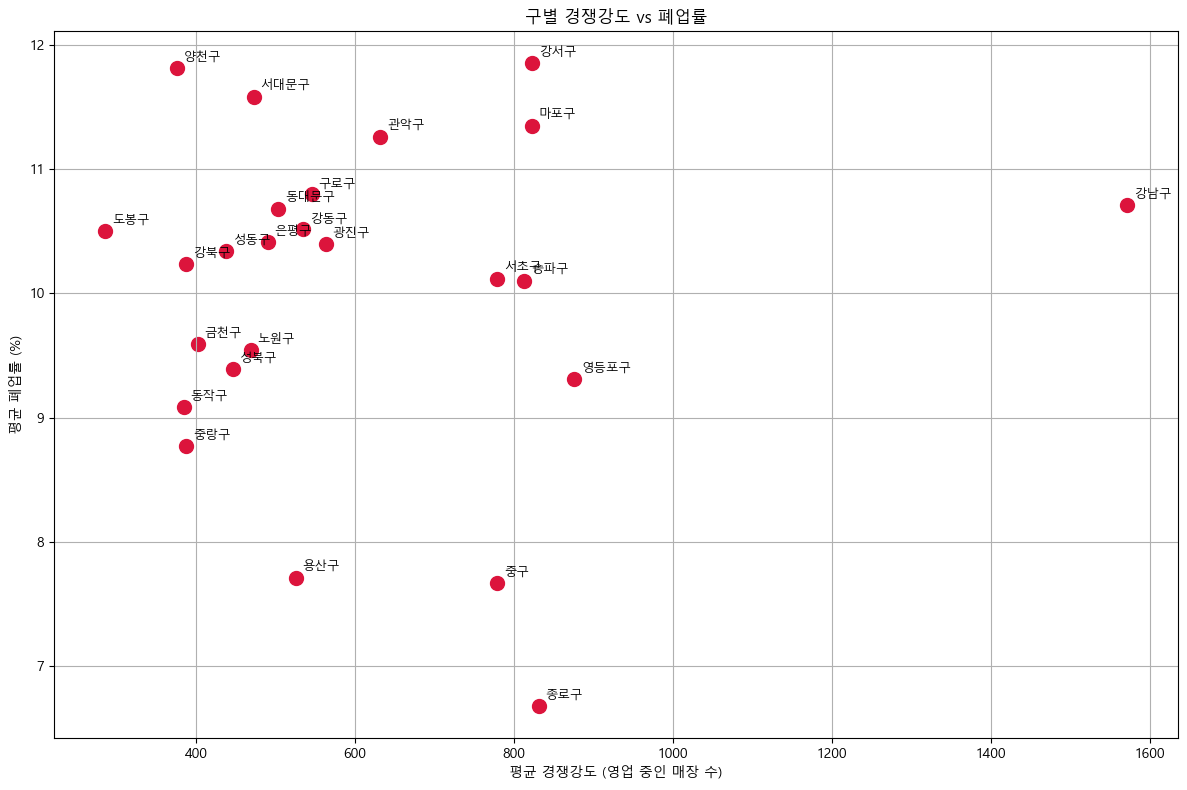

In [36]:
df_comp_scatter = df.groupby('구명').agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_comp_scatter['평균_경쟁강도'],
            df_comp_scatter['평균_폐업률'],
            s=100, color='crimson')

for _, row in df_comp_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_경쟁강도'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 경쟁강도 vs 폐업률')
plt.xlabel('평균 경쟁강도 (영업 중인 매장 수)')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

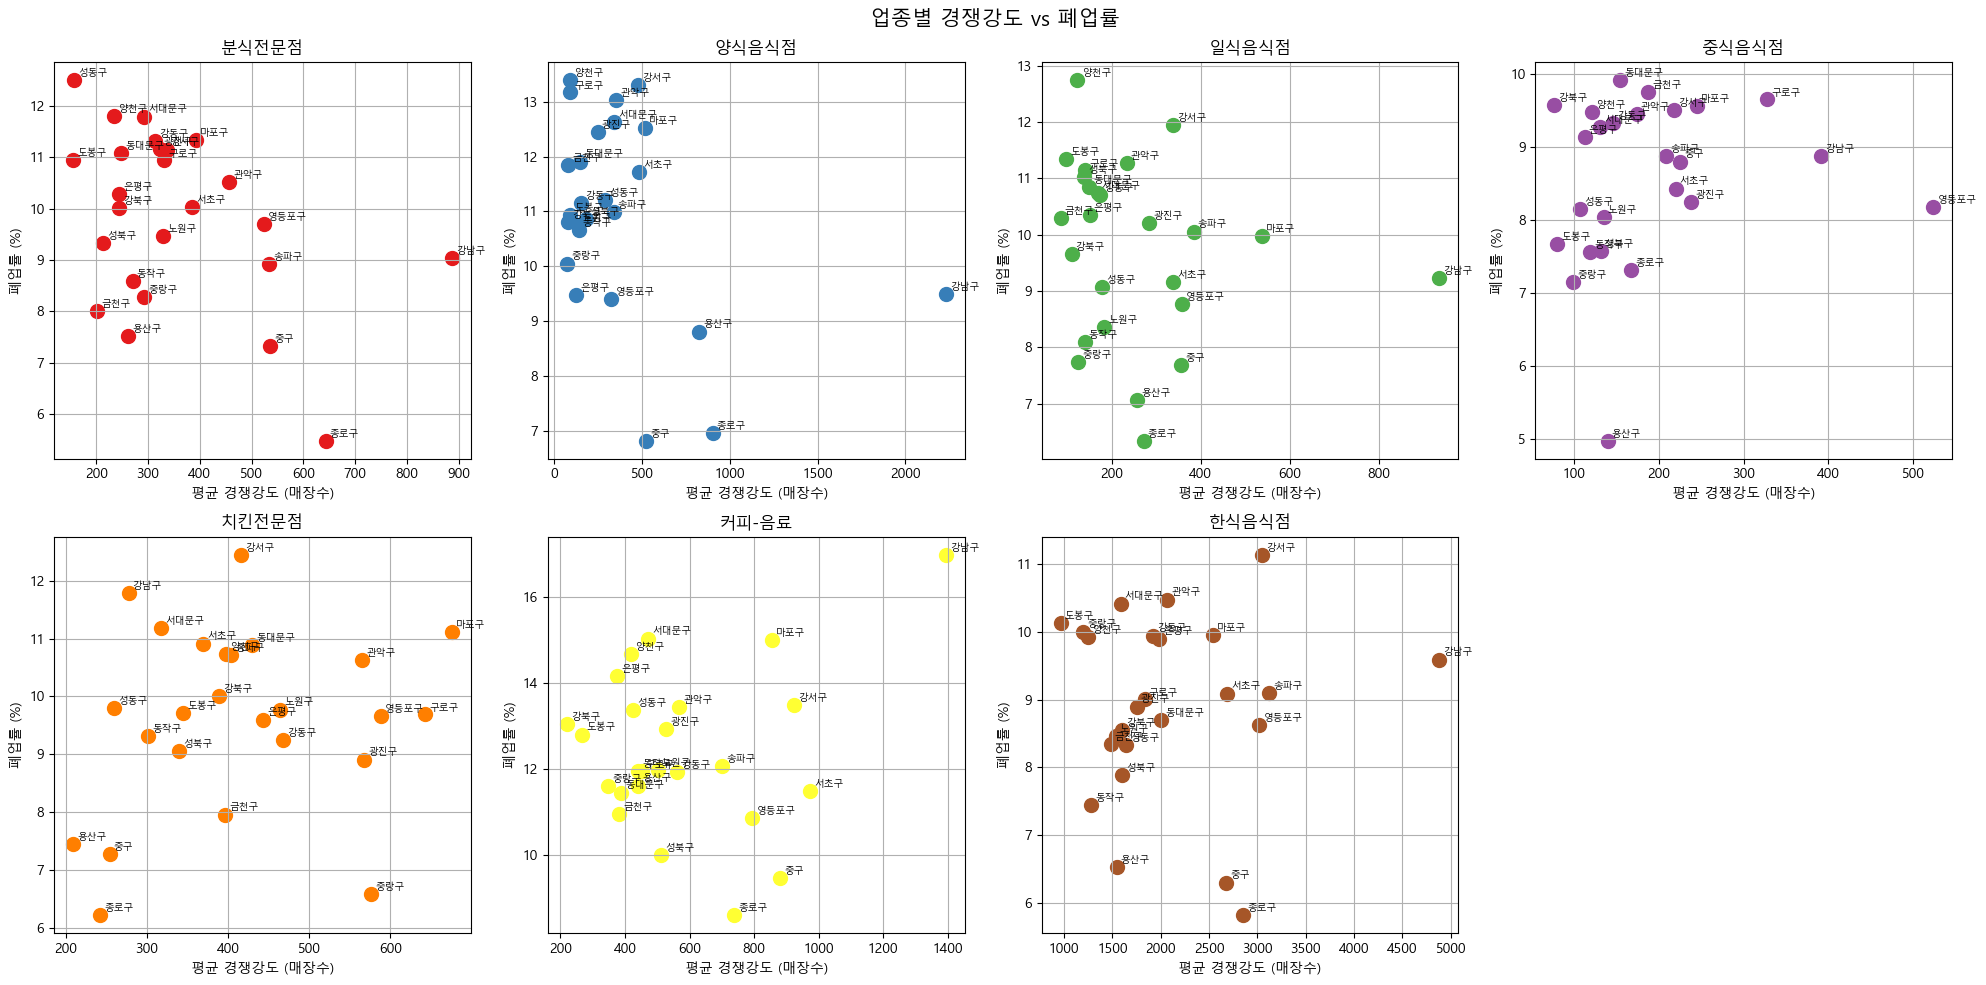

In [16]:
df_comp_scatter = df.groupby(['구명', '업종']).agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

# 업종별로 나눠서 보기
업종목록 = df_comp_scatter['업종'].unique()
colors = plt.cm.Set1.colors

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    axes[i].scatter(temp['평균_경쟁강도'],
                    temp['평균_폐업률'],
                    s=100, color=colors[i])
    for _, row in temp.iterrows():
        axes[i].annotate(row['구명'],
                        (row['평균_경쟁강도'], row['평균_폐업률']),
                        fontsize=7, xytext=(3,3),
                        textcoords='offset points')
    axes[i].set_title(f'{업종}')
    axes[i].set_xlabel('평균 경쟁강도 (매장수)')
    axes[i].set_ylabel('폐업률 (%)')
    axes[i].grid(True)

axes[-1].set_visible(False)
plt.suptitle('업종별 경쟁강도 vs 폐업률', fontsize=15)
plt.tight_layout()
plt.show()

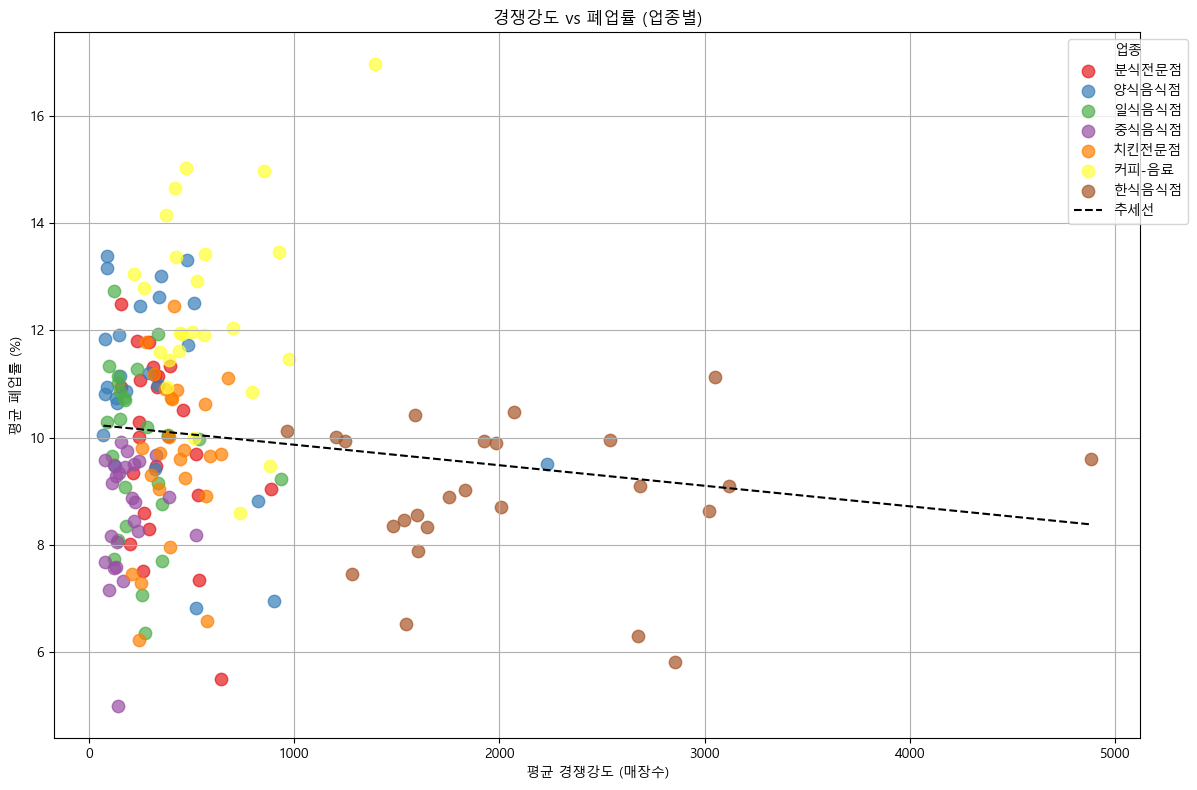

In [17]:
plt.figure(figsize=(12, 8))

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    plt.scatter(temp['평균_경쟁강도'],
                temp['평균_폐업률'],
                s=80, color=colors[i], label=업종, alpha=0.7)

# 추세선 추가
import numpy as np
x = df_comp_scatter['평균_경쟁강도']
y = df_comp_scatter['평균_폐업률']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(sorted(x), p(sorted(x)), color='black', linestyle='--', label='추세선')

plt.title('경쟁강도 vs 폐업률 (업종별)')
plt.xlabel('평균 경쟁강도 (매장수)')
plt.ylabel('평균 폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 경쟁강도 와 비교 해도 강남구 제외하면 약함
#### 임대료와 경쟁강도를 추가 변수로 투입했으나 EDA 단계에서는 폐업률과의 직접적 상관관계가 뚜렷하지 않았다. 
#### 이는 단일 변수보다 복합적 요인이 폐업에 영향을 준다는 것을 시사한다

### 종합
#### 유동인구의 함정  사람이 많다고 장사가 잘 되는 게 아니다 → 유동인구보다 직장인 고정수요가 핵심
#### 코로나 착시와 폐업 폭탄 2020 ~ 2021 → 지원금으로 폐업 억제  →
#### 2022~2024 → 지원 종료 + 고물가 → 폐업 급등
#### 업종 선택이 생존을 결정한다 어디서 창업하느냐보다 뭘 창업하느냐가 중요
#### 커피 → 전 지역 폐업률 1위 (평균 생존 2~4년)
#### 중식/한식 → 전 지역 안정적 (평균 생존 8~10년)
#### 강남구 커피 → 2.1년 (서울 평균 3.9년의 절반)

##### 유동인구가 많은 곳이 아니라, 직장인 고정수요가 있고 경쟁이 덜한 곳에서 안정적 업종으로 창업하는 것이 생존 확률을 높인다